In [33]:
import os
import numpy as np
import torch
from scipy.signal import resample_poly
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import time

In [34]:
def resize_time_axis(waterfall_data, target_size=1024):
    """
    Resize the time axis of a waterfall data.
    - Upsample using linear interpolation if size < target_size
    - Downsample using windowed sinc interpolation if size > target_size
    
    Parameters:
    waterfall_data (ndarray): Original 2D array of shape (frequency, time)
    
    Returns:
    ndarray: Resized 2D array of shape (frequency, target_size)
    """
    
    frequency_axis_size, time_axis_size = waterfall_data.shape
    resized_data = np.zeros((frequency_axis_size, target_size))
    
    original_time = np.arange(time_axis_size)
    target_time = np.linspace(0, time_axis_size - 1, target_size)
    
    for f in range(frequency_axis_size):
        if time_axis_size < target_size:  # Upsample using linear interpolation
            interp_function = interp1d(original_time, waterfall_data[f, :], kind='linear')
            resized_data[f, :] = interp_function(target_time)
            
        elif time_axis_size > target_size:  # Downsample using windowed sinc method
            resized_data[f, :] = resample_poly(waterfall_data[f, :], target_size, time_axis_size)
            
        else:  # If time_axis_size is already target_size, just return the original data
            resized_data[f, :] = waterfall_data[f, :]
    
    return resized_data

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #Remember to install the GPU version of Pytorch!!!!!!
print(f"Using device: {device}")

Using device: cuda


In [36]:
########################
class FRB_CNN_LSTM_3Conv(nn.Module):
    def __init__(self, lstm_hidden_size=128, num_lstm_layers=2):
        super(FRB_CNN_LSTM_3Conv, self).__init__()

        # Conv1
        self.conv1 = nn.Conv1d(
            in_channels=512, out_channels=32, kernel_size=5, stride=1, padding=2
        )
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(kernel_size=2, stride=2)

        # Conv2
        self.conv2 = nn.Conv1d(
            in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1
        )
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(kernel_size=2, stride=2)

        # Conv3
        self.conv3 = nn.Conv1d(
            in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1
        )
        self.bn3 = nn.BatchNorm1d(128)

        # Conv4
        self.conv4 = nn.Conv1d(
            in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1
        )
        self.bn4 = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(kernel_size=2, stride=2)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=256, hidden_size=lstm_hidden_size, num_layers=num_lstm_layers,
            batch_first=True, bidirectional=True
        )

        # Fully-connected
        self.fc1 = nn.Linear(lstm_hidden_size * 2, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        x = x.squeeze(1)  # (batch, 512, 1024)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        #plt.imshow(x.squeeze(0)) #Show hidden states
        #plt.show()
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        #plt.imshow(x.squeeze(0))
        #plt.show()
        x = F.relu(self.bn3(self.conv3(x)))
        #plt.imshow(x.squeeze(0))
        #plt.show()
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool3(x)
        #plt.imshow(x.squeeze(0))
        #plt.show()
        x = x.permute(0, 2, 1)
        x, _ = self.lstm(x)
        #plt.imshow(x.squeeze(0))
        #plt.show()
        x = x[:, -1, :]
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
checkpoint = torch.load("checkpoint_path\\weights_file.pth", map_location=device)
model = FRB_CNN_LSTM_3Conv(lstm_hidden_size=128, num_lstm_layers=2).to(device)
model.load_state_dict(checkpoint['state_dict'])
model.eval()

FRB_CNN_LSTM_3Conv(
  (conv1): Conv1d(512, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (lstm): LSTM(256, 128, num_layers=2, batch_first=True, bidirectional=True)

['wfall', 'params']


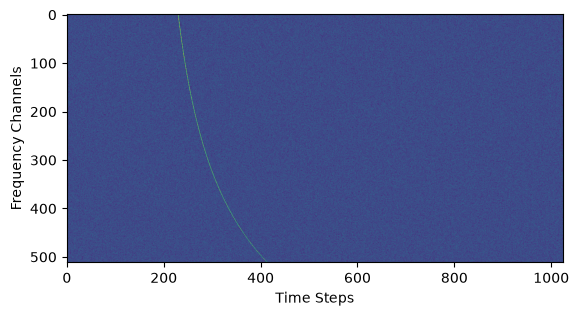

In [45]:
raw_data = np.load("data_path\\waterfall_data.npz", allow_pickle=True)
print(raw_data.files)
frbs = raw_data['wfall']
tensor_frbs = torch.from_numpy(frbs.astype(np.float32)).unsqueeze(0).to(device)
plt.imshow(frbs)
plt.xlabel("Time Steps")
plt.ylabel("Frequency Channels")
plt.show()

In [46]:
predicted_dm = model(tensor_frbs).item()
ground_truth_dm = raw_data['params'][0]

print(f'prediction: {predicted_dm}')
print(f'ground truth: {ground_truth_dm}')

prediction: 112.30311584472656
ground truth: 112.5986988901877
